# ICA Applied to Image Unmixing

This notebook demonstrates Independent Component Analysis (ICA) for the blind source separation of image mixtures, following Example 12.3 (p. 258) of Hyvärinen, Karhunen & Oja (2001).

Dataset: `dataset/image/run<N>/mix_imagens_*.csv` — one CSV per run, one column per source, each column a flattened image.

**Known open issues (see `todo.md`):**
- The RGB channel grouping (`run3`, 9 columns) hasn't been confirmed — each column here is treated as an independent channel, without reconstructing a color image.
- The source count on disk (`run1`=3, `run3`=9) doesn't match the assignment brief (2/3/4), and there is no `run2`.

In [1]:
import base64
from io import BytesIO
from math import isqrt
from pathlib import Path

import pandas as pd
import torch
from IPython.display import HTML, display
from PIL import Image

from ica.data.image import ImageDataset
from ica.model import Kurtosis, Negentropy
from ica.preprocessing import Centering, Whitening
from ica.utils import Pipeline

torch.manual_seed(0)

DATASET_DIR = Path("../../../dataset/image")


def to_pil(image: torch.Tensor) -> Image.Image:
    """Rescale to [0, 255] for display; ICA leaves scale/sign arbitrary."""
    image = image - image.min()
    image = image / image.max()
    return Image.fromarray((image * 255).round().numpy().astype("uint8"), mode="L")


def _data_uri(image: Image.Image) -> str:
    buffer = BytesIO()
    image.save(buffer, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")


def display_images(images, label):
    """Show PIL images side by side instead of stacked."""
    blocks = "".join(
        f'<div style="display:inline-block; margin-right:1em; text-align:center;">'
        f'<div>{label} {i}</div><img src="{_data_uri(image)}"></div>'
        for i, image in enumerate(images)
    )
    display(HTML(blocks))


def side_by_side(*named_items):
    """Show labeled matrices next to each other."""
    blocks = "".join(
        f'<div style="display:inline-block; margin-right:2em; vertical-align:top;">'
        f"<b>{name}</b>{pd.DataFrame(matrix.numpy()).to_html()}</div>"
        for name, matrix in named_items
    )
    display(HTML(blocks))


def prepare_and_compare(dataset, methods):
    """Center and whiten once, then fit_transform every method on that checkpoint."""
    whitening = Whitening()
    Z = Pipeline(steps=[Centering(), whitening]).fit_transform(dataset)

    results = {}
    for name, model in methods.items():
        torch.manual_seed(0)
        results[name] = model.fit_transform(Z)

    mixing_matrices = {
        name: torch.linalg.inv(whitening.whitening_matrix) @ model.components.T
        for name, model in methods.items()
    }
    return results, mixing_matrices

## `run1` — grayscale (3 sources)

In [2]:
run1 = ImageDataset(source=next((DATASET_DIR / "run1").glob("*.csv")), alias="run1")
run1

ImageDataset(alias='run1', path=PosixPath('../../../dataset/image/run1/mix_imagens_grayscale.csv'), X_shape=(3, 16384))

### Original mixtures


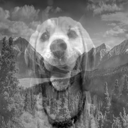
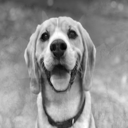
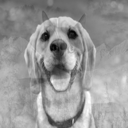

In [3]:
display_images([to_pil(run1.to_image(i)) for i in range(len(run1))], "mixture")

### Apply every ICA method to the same prepared data

In [4]:
methods = {"Kurtosis": Kurtosis(), "Negentropy": Negentropy()}
results, mixing_matrices = prepare_and_compare(run1, methods)

### Recovered mixing matrices

In [5]:
side_by_side(*mixing_matrices.items())

,0,1,2
0,0.022510,-0.126961,0.104357
1,-0.113407,0.052905,0.275571
2,-0.241627,0.067355,0.208978
,0,1,2
0,-0.081017,0.004777,0.144671
1,-0.046925,-0.274936,0.117507
2,0.097667,-0.288219,0.118249


### Separated sources


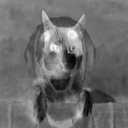
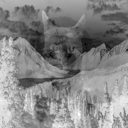
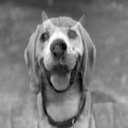


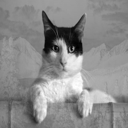
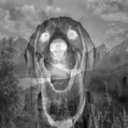
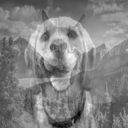

In [6]:
side = isqrt(next(iter(results.values())).shape[1])

for name, Y in results.items():
    display(HTML(f"<h4>{name}</h4>"))
    display_images([to_pil(source.reshape(side, side)) for source in Y], "source")

## `run3` — RGB, 9 columns treated as independent channels

No confirmation yet of the R/G/B channel grouping (see the open issue at the top) — each column is separated in isolation, as if it were grayscale.

In [7]:
run3 = ImageDataset(source=next((DATASET_DIR / "run3").glob("*.csv")), alias="run3")
run3

ImageDataset(alias='run3', path=PosixPath('../../../dataset/image/run3/mix_imagens_rgb.csv'), X_shape=(9, 16384))

### Original mixtures


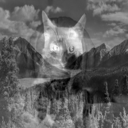
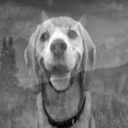
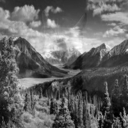
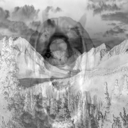
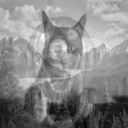
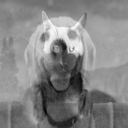
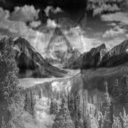
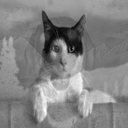
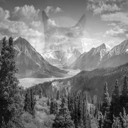

In [8]:
display_images([to_pil(run3.to_image(i)) for i in range(len(run3))], "mixture")

### Apply every ICA method to the same prepared data

In [9]:
methods_3 = {"Kurtosis": Kurtosis(), "Negentropy": Negentropy()}
results_3, mixing_matrices_3 = prepare_and_compare(run3, methods_3)

### Recovered mixing matrices

In [10]:
side_by_side(*mixing_matrices_3.items())

,0,1,2,3,4,5,6,7,8
0,0.257108,-0.284892,-0.079201,-0.139895,0.349314,-0.095708,0.181199,0.251507,-0.342476
1,-0.046029,-0.283401,-0.321438,0.040443,-0.235043,-0.069254,0.129426,-0.000039,-0.140566
2,-0.026357,-0.162052,-0.138319,-0.094536,0.080892,0.057072,0.225168,0.213124,-0.204788
3,-0.168006,0.148326,0.242620,0.000485,0.047596,-0.001770,-0.243457,-0.169243,0.326852
4,-0.263237,-0.055694,-0.008589,-0.156544,0.073949,0.015843,0.317380,0.085959,0.148389
5,-0.204467,-0.246288,-0.128589,-0.113207,-0.032825,-0.053193,-0.044588,-0.012084,-0.100707
6,0.069300,-0.040606,0.012625,0.081746,0.010082,0.103288,0.171773,0.093511,-0.151097
7,0.013348,0.192608,0.118136,0.011240,-0.051747,0.118910,0.027291,0.018859,0.130043
8,-0.322900,-0.368581,-0.382726,-0.182758,0.005935,-0.224654,0.995722,0.308590,-0.090381
,0,1,2,3,4,5,6,7,8


### Separated sources


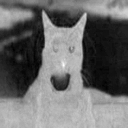
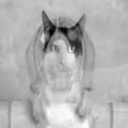
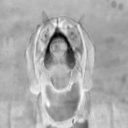
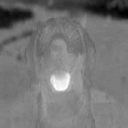
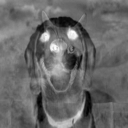
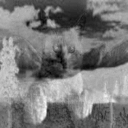
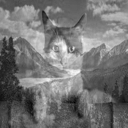
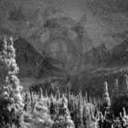
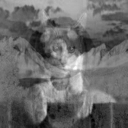


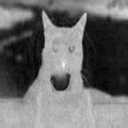
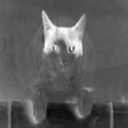
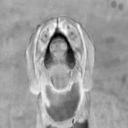
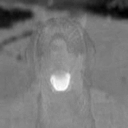
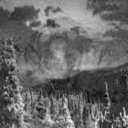
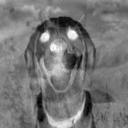
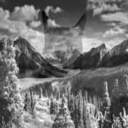
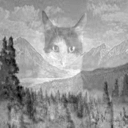
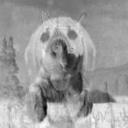

In [11]:
side_3 = isqrt(next(iter(results_3.values())).shape[1])

for name, Y in results_3.items():
    display(HTML(f"<h4>{name}</h4>"))
    display_images([to_pil(source.reshape(side_3, side_3)) for source in Y], "source")